# Clase 7 Análisis de Datos

## 20260509

Librerías

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import re
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder
import math
from sklearn.mixture import GaussianMixture
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import json
from datetime import datetime
from pathlib import Path

Descripción de variables, paso 1 definición de variable objetivo

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

Paso 2 importar datos

In [4]:
compu_df = pd.read_csv("../INPUTS/computer_prices_all.csv")

# https://www.kaggle.com/datasets/paperxd/all-computer-prices

Paso 3 Analisis exploratorio

In [5]:
compu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  cpu_base_ghz         100000 non-null  float64
 12  cpu_boost_ghz        100000 non-null  float64
 13  gpu_brand            100000 non-null  object 
 14  gpu_model            100000 non-null  object 
 15  gpu_tier          

In [6]:
# conteo de variables por tipo de dato
compu_df.dtypes.value_counts()

int64      14
object     13
float64     6
Name: count, dtype: int64

In [7]:
# valores unicos por columna
compu_df.nunique().sort_values(ascending=False).to_frame(name="nunique")

,nunique
model,99036
cpu_model,26971
price,3366
gpu_model,49
weight_kg,47
cpu_threads,25
cpu_boost_ghz,18
ram_gb,15
cpu_cores,12
brand,10


In [8]:
# duplicados
n_dup = compu_df.duplicated().sum()
pct_dup = (n_dup / len(compu_df) * 100) if len(compu_df) > 0 else 0
print(f"Número de filas duplicadas: {n_dup} ({pct_dup:.2f}%)")

Número de filas duplicadas: 0 (0.00%)


In [9]:
# missings por columna
missing_counts = compu_df.isnull().sum()
missing_percentages = ((missing_counts / len(compu_df) * 100).round(2)) if len(compu_df) > 0 else 0
missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percentage': missing_percentages
}).sort_values(by='missing_percentage', ascending=False)

display(missing_df)

,missing_count,missing_percentage
device_type,0,0.0
brand,0,0.0
model,0,0.0
release_year,0,0.0
os,0,0.0
form_factor,0,0.0
cpu_brand,0,0.0
cpu_model,0,0.0
cpu_tier,0,0.0
cpu_cores,0,0.0


In [10]:
# estadisticas descriptivas de variables numericas
numeric_cols = compu_df.select_dtypes(include=[np.number]).columns.tolist()
base_num = compu_df[numeric_cols]
n_rows = base_num.shape[0]
desc = base_num.describe(percentiles=[0.01,0.05,0.25, 0.5, 0.75, 0.95, 0.99]).T

desc["n_unicos"] = base_num.nunique()
desc["n_missings"] = base_num.isnull().sum()
desc["pct_missings"] = (desc["n_missings"] / n_rows * 100) if n_rows > 0 else 0
desc["skew"] = base_num.skew()
desc["kurt"] = base_num.kurtosis()

cols_orden = ["count","mean", "std", "min", "1%", "5%", "25%", "50%", "75%", "95%", "99%", "max","n_missings","pct_missings" ,"skew", "kurt"]

desc = desc[cols_orden]

display(desc)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,n_missings,pct_missings,skew,kurt
release_year,100000.0,2022.320850,2.025761,2018.00,2018.00,2018.00,2021.00,2023.00,2024.00,2025.00,2025.00,2025.00,0,0.0,-0.479062,-0.715846
cpu_tier,100000.0,3.153490,1.373175,1.00,1.00,1.00,2.00,3.00,4.00,5.00,6.00,6.00,0,0.0,0.174307,-0.751699
cpu_cores,100000.0,10.515740,5.044092,4.00,4.00,4.00,6.00,8.00,14.00,20.00,26.00,28.00,0,0.0,1.087762,1.007646
cpu_threads,100000.0,19.372700,9.718426,4.00,6.00,8.00,12.00,16.00,24.00,36.00,52.00,56.00,0,0.0,1.125744,1.300012
cpu_base_ghz,100000.0,2.591322,0.336435,2.00,2.00,2.00,2.40,2.60,2.80,3.20,3.40,3.40,0,0.0,0.172064,-0.520792
cpu_boost_ghz,100000.0,3.531310,0.350024,2.80,2.80,3.00,3.30,3.50,3.80,4.10,4.30,4.50,0,0.0,0.149925,-0.451167
gpu_tier,100000.0,2.991350,1.459643,1.00,1.00,1.00,2.00,3.00,4.00,6.00,6.00,6.00,0,0.0,0.285752,-0.851269
vram_gb,100000.0,6.152180,3.964926,0.00,0.00,0.00,4.00,6.00,8.00,12.00,16.00,16.00,0,0.0,0.281362,-0.354864
ram_gb,100000.0,39.706400,31.902684,8.00,8.00,8.00,16.00,32.00,64.00,96.00,128.00,144.00,0,0.0,1.049278,0.195870
storage_gb,100000.0,903.936000,774.243654,256.00,256.00,256.00,512.00,512.00,1024.00,2048.00,4096.00,4096.00,0,0.0,2.304037,6.272154


Text(0.5, 1.0, 'Distribución de cpu_tier')

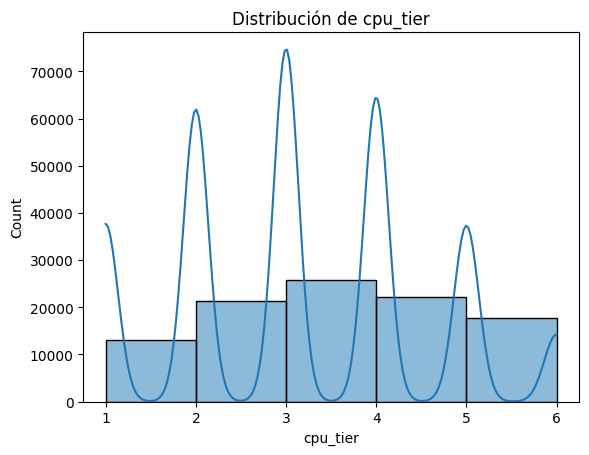

In [11]:
# histograma de cpu_tier
sns.histplot(data=compu_df, x="cpu_tier", bins=5, kde=True)
plt.title("Distribución de cpu_tier")

In [12]:
# estadisticas descriptivas de variables categoricas (tabla de frecuencias)

cat_types = ["object", "category", "bool", "string"]
columnas_cat = compu_df.select_dtypes(include=cat_types).columns.tolist()
n_total = len(compu_df)
resumen_rows = []

for col in columnas_cat:
    s = compu_df[col]
    vc = s.value_counts(dropna=False)
    niveles_totales = int(len(vc))
    unicos_no_na = int(s.nunique(dropna=True))
    na_count = int(s.isna().sum())
    na_pct = (na_count / n_total * 100.0) if n_total > 0 else 0.0
    top = vc
    freq_df = top.reset_index()
    freq_df.columns = [col, 'frecuencia']

    freq_df['valor'] = freq_df[col].apply(lambda x: 'NaN' if pd.isna(x) else str(x))
    freq_df = freq_df.drop(columns=[col])

    if n_total > 0:
        freq_df['%'] = (freq_df['frecuencia'] / n_total * 100.0).round(2)
    else:
        freq_df['%'] = 0.0

    if niveles_totales > len(top):
        otros_cnt = int(vc.iloc[len(top):].sum())
        otros_pct = (otros_cnt / n_total * 100.0) if n_total > 0 else 0.0
        freq_df = pd.concat([freq_df,pd.DataFrame({'valor': ['Otros'], 'frecuencia': [otros_cnt], '%': [round(otros_pct, 2)]})],ignore_index=True)

    freq_df['%_acum'] = freq_df['%'].cumsum().round(2)
    freq_df.insert(0, 'rank', np.arange(1, len(freq_df) + 1))
    resumen_rows.append({'columna': col,'unicos': niveles_totales,'unicos_no_na': unicos_no_na,
                         'NA': na_count,'%_NA': round(na_pct, 2),'frecuencia': n_total})

resumen = pd.DataFrame(resumen_rows)
resumen = resumen.sort_values(['frecuencia', 'unicos_no_na'], ascending=False)

display(resumen)

,columna,unicos,unicos_no_na,NA,%_NA,frecuencia
2,model,99036,99036,0,0.0,100000
6,cpu_model,26971,26971,0,0.0,100000
8,gpu_model,49,49,0,0.0,100000
1,brand,10,10,0,0.0,100000
4,form_factor,10,10,0,0.0,100000
10,display_type,6,6,0,0.0,100000
11,resolution,6,6,0,0.0,100000
3,os,4,4,0,0.0,100000
7,gpu_brand,4,4,0,0.0,100000
9,storage_type,4,4,0,0.0,100000


In [13]:
# frecuencia por variable para categóricas

for col in columnas_cat:
    s = compu_df[col]
    vc = s.value_counts(dropna=False)

    freq_df = (vc.rename('frecuencia').reset_index().rename(columns={'index': col}))
    freq_df[col] = freq_df[col].astype(object).where(~freq_df[col].isna(), 'NaN').astype(str)
    freq_df['%'] = (freq_df['frecuencia'] / n_total * 100.0).round(2)
    freq_df['%_acum'] = freq_df['%'].cumsum().round(2)
    freq_df.insert(0, 'rank', np.arange(1, len(freq_df) + 1))

    display(freq_df)

,rank,device_type,frecuencia,%,%_acum
0,1,Laptop,59844,59.84,59.84
1,2,Desktop,40156,40.16,100.00


,rank,brand,frecuencia,%,%_acum
0,1,Lenovo,15992,15.99,15.99
1,2,HP,14114,14.11,30.10
2,3,Dell,14005,14.00,44.10
3,4,Apple,11915,11.92,56.02
4,5,ASUS,10159,10.16,66.18
5,6,Acer,9925,9.93,76.11
6,7,Samsung,8066,8.07,84.18
7,8,MSI,7891,7.89,92.07
8,9,Gigabyte,4900,4.90,96.97
9,10,Razer,3033,3.03,100.00


,rank,model,frecuencia,%,%_acum
0,1,HP Creator R41,3,0.0,0.0
1,2,HP Pro K9S,3,0.0,0.0
2,3,Lenovo Think 0V5,3,0.0,0.0
3,4,ASUS Slim R6S,3,0.0,0.0
4,5,Acer Creator 3U0,3,0.0,0.0
...,...,...,...,...,...
99031,99032,Apple Slim NO0,1,0.0,0.0
99032,99033,Dell Blade K5G,1,0.0,0.0
99033,99034,Dell Pro ALV,1,0.0,0.0
99034,99035,Acer Think C5Y,1,0.0,0.0


,rank,os,frecuencia,%,%_acum
0,1,Windows,71817,71.82,71.82
1,2,macOS,18207,18.21,90.03
2,3,Linux,6109,6.11,96.14
3,4,ChromeOS,3867,3.87,100.01


,rank,form_factor,frecuencia,%,%_acum
0,1,Mainstream,17819,17.82,17.82
1,2,Gaming,16876,16.88,34.70
2,3,ATX,15597,15.60,50.30
3,4,Ultrabook,13236,13.24,63.54
4,5,Micro-ATX,8672,8.67,72.21
5,6,Full-Tower,7110,7.11,79.32
6,7,2-in-1,7049,7.05,86.37
7,8,SFF,5585,5.58,91.95
8,9,Workstation,4864,4.86,96.81
9,10,Mini-ITX,3192,3.19,100.00


...

,rank,gpu_model,frecuencia,%,%_acum
0,1,Apple Integrated,18922,18.92,18.92
1,2,RTX 40 70,5743,5.74,24.66
2,3,RTX 30 70,5692,5.69,30.35
3,4,RTX 40 60,5437,5.44,35.79
4,5,RTX 30 60,5314,5.31,41.10
5,6,RTX 30 50,5046,5.05,46.15
6,7,RTX 40 50,4970,4.97,51.12
7,8,RTX 40 80,4676,4.68,55.80
8,9,RTX 30 80,4618,4.62,60.42
9,10,RTX 30 80 Ti,2752,2.75,63.17


,rank,storage_type,frecuencia,%,%_acum
0,1,NVMe,45059,45.06,45.06
1,2,SSD,24937,24.94,70.00
2,3,HDD,15023,15.02,85.02
3,4,Hybrid,14981,14.98,100.00


,rank,display_type,frecuencia,%,%_acum
0,1,LED,32000,32.00,32.00
1,2,OLED,21910,21.91,53.91
2,3,IPS,17742,17.74,71.65
3,4,Mini-LED,12188,12.19,83.84
4,5,QLED,10069,10.07,93.91
5,6,VA,6091,6.09,100.00


,rank,resolution,frecuencia,%,%_acum
0,1,1920x1080,47993,47.99,47.99
1,2,2560x1600,14887,14.89,62.88
2,3,2560x1440,14509,14.51,77.39
3,4,3840x2160,10950,10.95,88.34
4,5,2880x1800,5954,5.95,94.29
5,6,3440x1440,5707,5.71,100.00


,rank,wifi,frecuencia,%,%_acum
0,1,Wi-Fi 6,46149,46.15,46.15
1,2,Wi-Fi 6E,25923,25.92,72.07
2,3,Wi-Fi 5,19926,19.93,92.00
3,4,Wi-Fi 7,8002,8.00,100.00


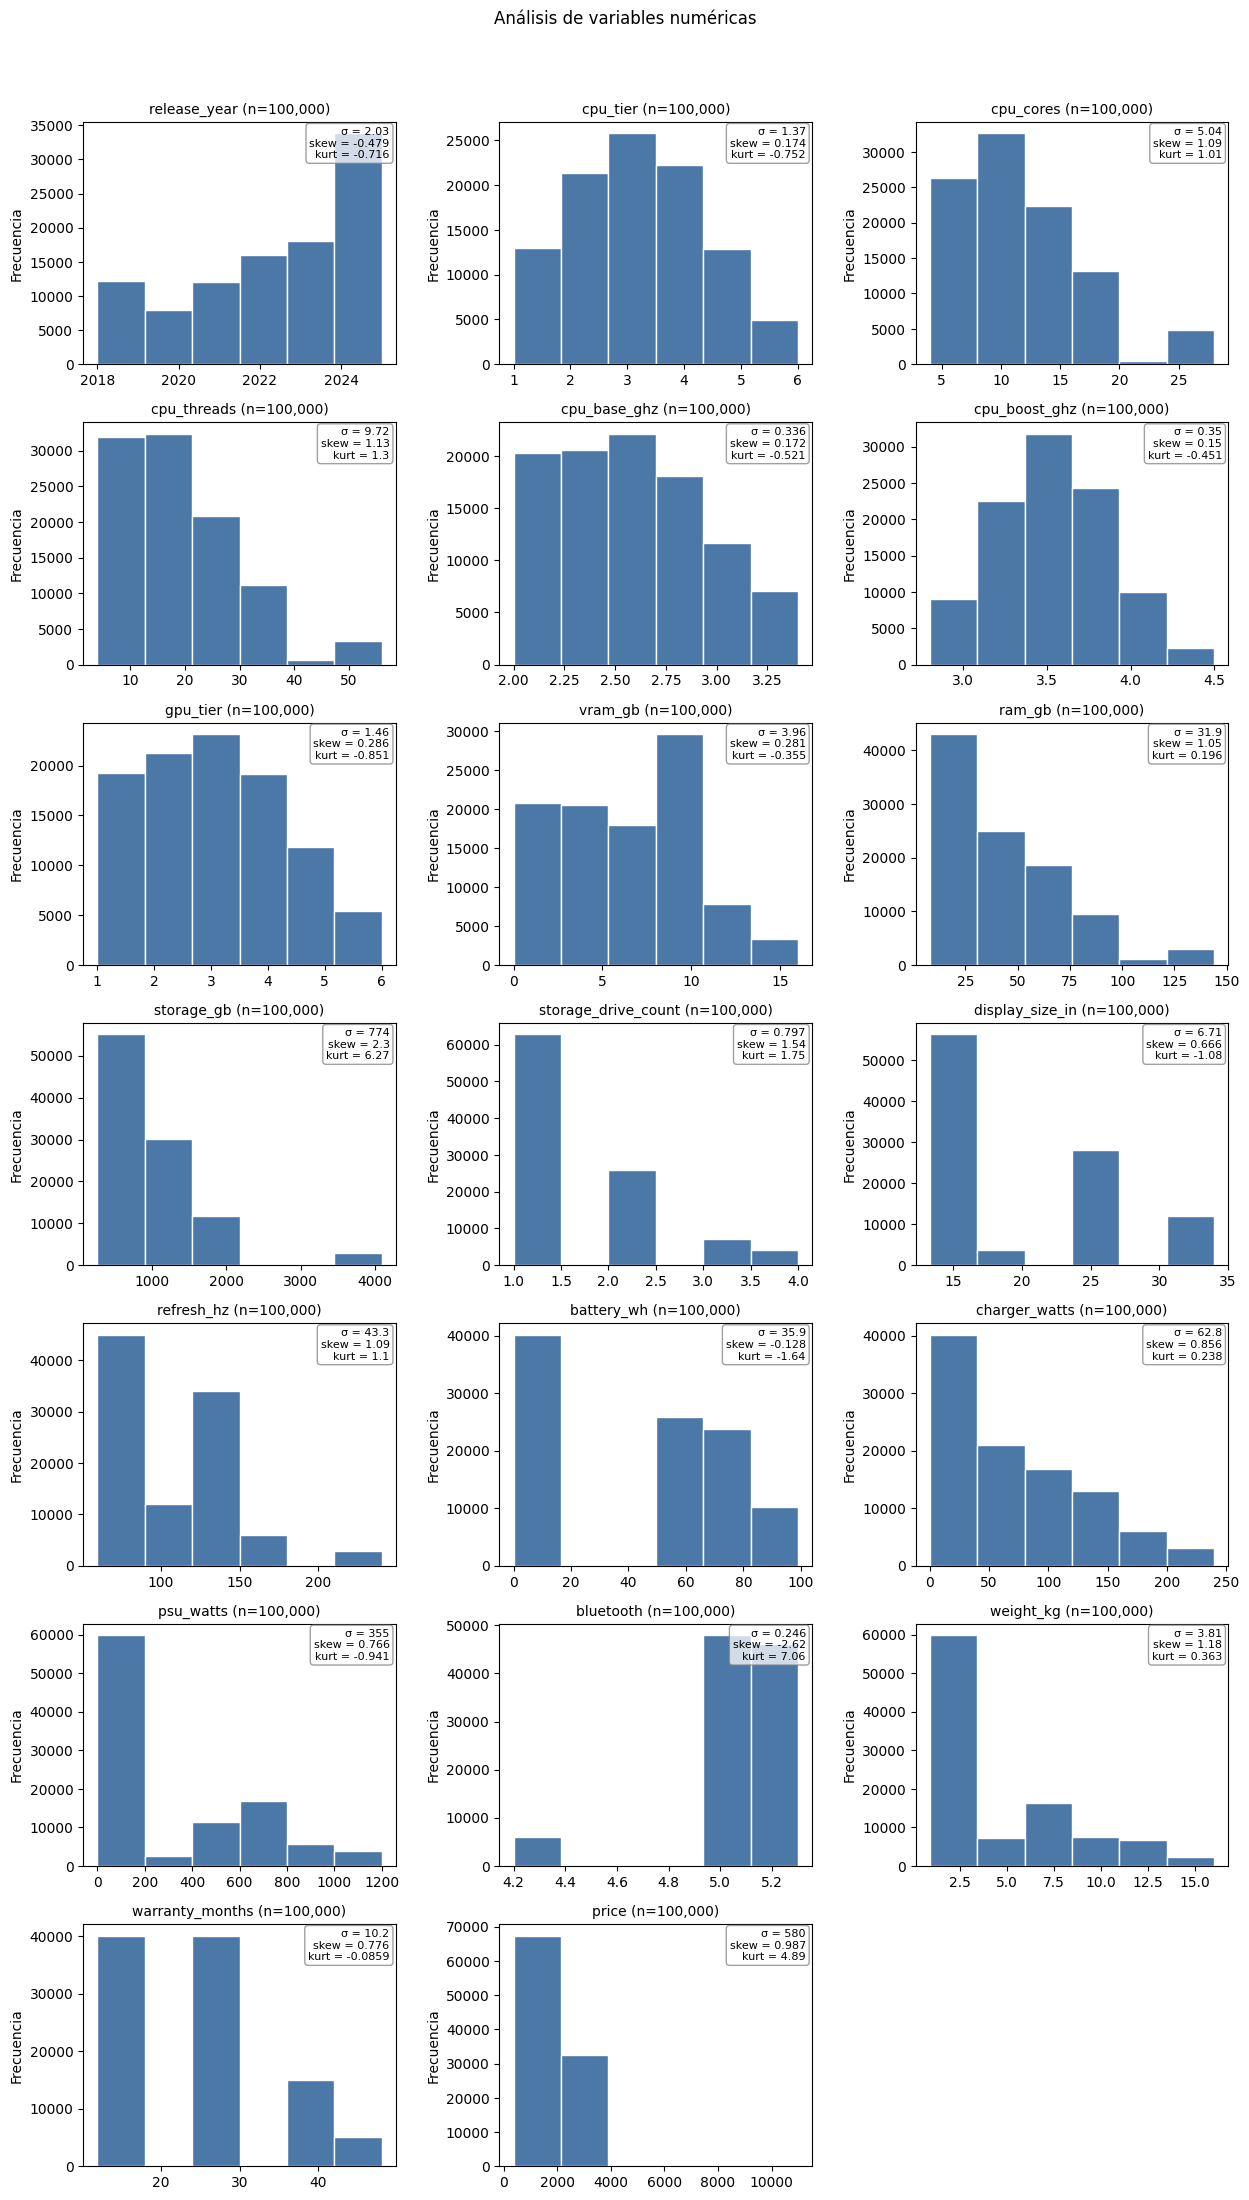

In [14]:
# Histogramas de variables numéricas
bins = 6
max_cols = 3
figsize_por_grafica = (4.2, 3.2)
titulo = "Análisis de variables numéricas"

columnas_numericas = compu_df.select_dtypes(include=[np.number]).columns.tolist()
n_cols = len(columnas_numericas)

ncols = min(max_cols, n_cols)
nrows = int(math.ceil(n_cols / ncols))

fig_w = figsize_por_grafica[0] * ncols
fig_h = figsize_por_grafica[1] * nrows
fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))

if nrows == 1 and ncols == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = np.array([axes])
elif ncols == 1:
    axes = np.array([[ax] for ax in axes])

for i, col in enumerate(columnas_numericas):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    serie = compu_df[col].dropna().astype(float)
    ax.hist(serie, bins=bins, color="#4C78A8", edgecolor="white")

    n = serie.size
    std = serie.std(ddof=1) if n > 1 else np.nan
    skew = serie.skew() if n > 0 else np.nan
    kurt = serie.kurt() if n > 0 else np.nan

    texto = f"σ = {std:.3g}\nskew = {skew:.3g}\nkurt = {kurt:.3g}"
    ax.text(0.98, 0.98, texto, transform=ax.transAxes, ha="right", va="top",
            fontsize=8, bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="gray"))

    ax.set_title(f"{col} (n={n:,})", fontsize=10)
    ax.set_ylabel("Frecuencia")
    ax.set_xlabel("")

total_subplots = nrows * ncols
for j in range(n_cols, total_subplots):
    r, c = divmod(j, ncols)
    axes[r, c].axis('off')

fig.suptitle(titulo, fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])

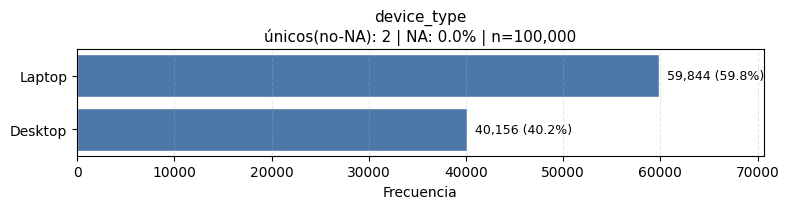

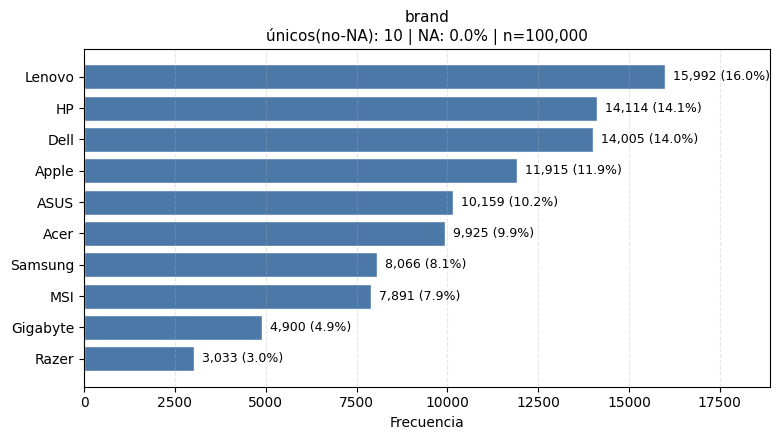

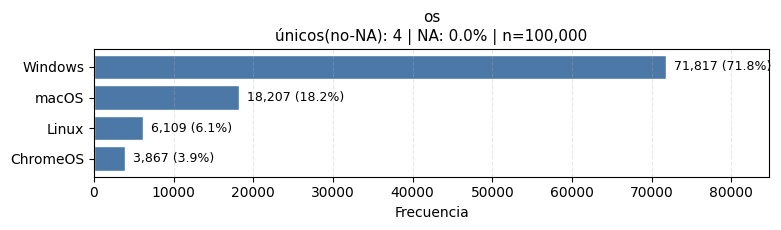

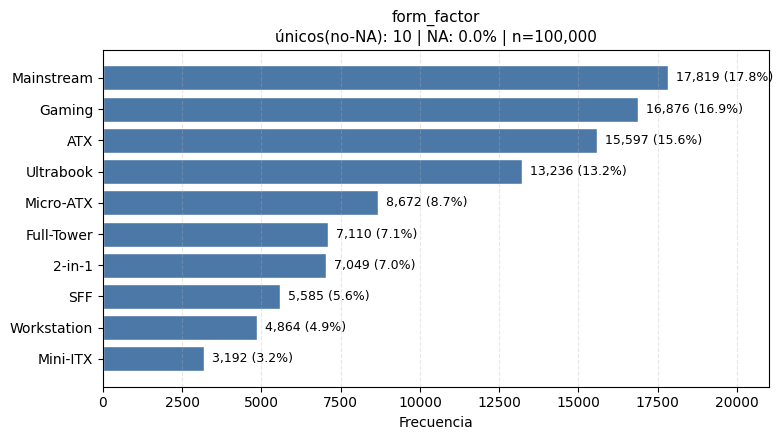

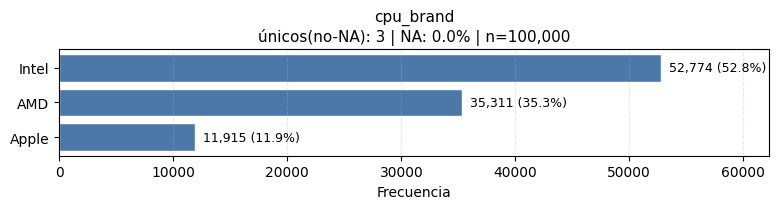

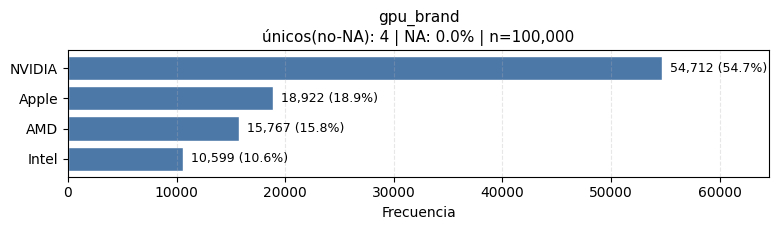

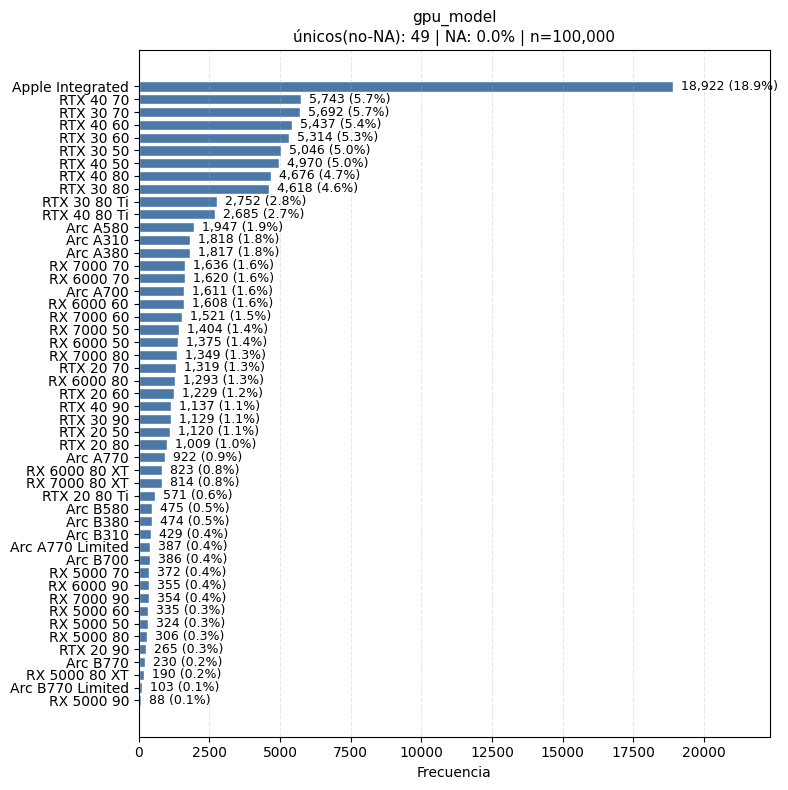

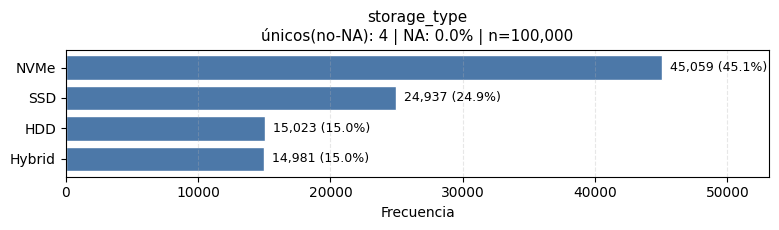

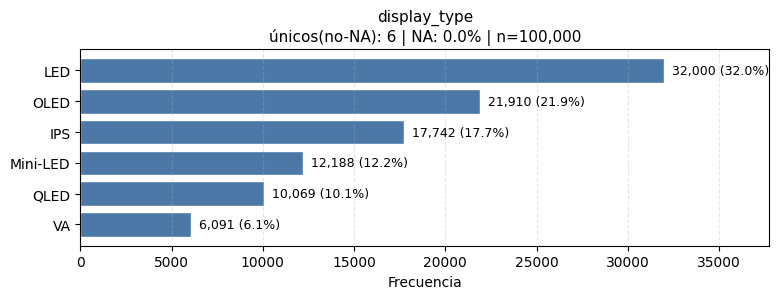

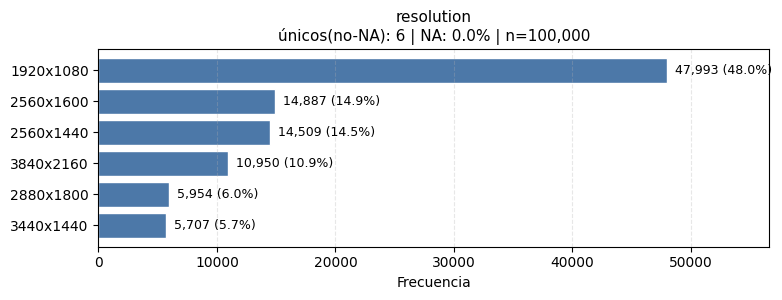

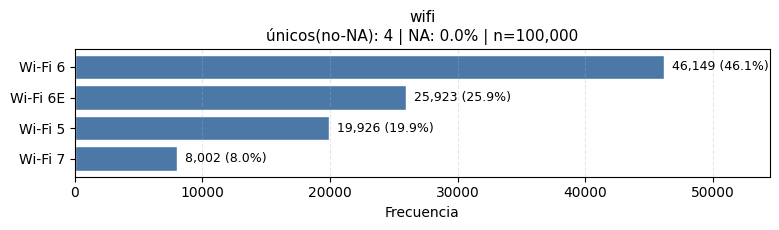

In [15]:
# visualización de variables categóricas (barras horizontales)

color_barras = "#4C78A8"

cat_types = ['object', 'string', 'category','bool']
columnas_cat = compu_df.select_dtypes(include=cat_types).columns.tolist()

# excluir compu_df.drop(columns=["model", "cpu_model"], inplace=True)
columnas_cat = [col for col in columnas_cat if col not in ["model", "cpu_model"]]

archivos_generados = []

n_total = len(compu_df)
for col in columnas_cat:
    s = compu_df[col]
    vc = s.value_counts(dropna=False)
    nunique = int(s.nunique(dropna=True))
    k = len(vc)
    vc_top = vc

    etiquetas = [("NaN" if pd.isna(x) else str(x)) for x in vc_top.index.tolist()]
    valores = vc_top.values
    porcentajes = (valores / n_total * 100.0)
    alto_por_barra = 0.35
    alto_min = 2.2
    alto_max = 8.0
    height = min(max(alto_min, alto_por_barra * len(etiquetas) + 1.0), alto_max)
    width = 8

    fig, ax = plt.subplots(figsize=(width, height))
    y_pos = np.arange(len(etiquetas))
    ax.barh(y_pos, valores, color=color_barras, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(etiquetas)
    ax.invert_yaxis()
    max_val = valores.max() if len(valores) > 0 else 1
    ax.set_xlim(0, max_val * 1.18)
    for y, (cnt, pct) in enumerate(zip(valores, porcentajes)):
        ax.text(cnt, y, f"  {cnt:,} ({pct:.1f}%)", va='center', ha='left', fontsize=9)

    na_pct = (s.isna().mean() * 100.0) if n_total > 0 else 0.0

    subtitulo = f"únicos(no-NA): {nunique} | NA: {na_pct:.1f}% | n={n_total:,}"
    ax.set_title(f"{col}\n{subtitulo}", fontsize=11)
    ax.set_xlabel("Frecuencia")
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    fig.tight_layout()


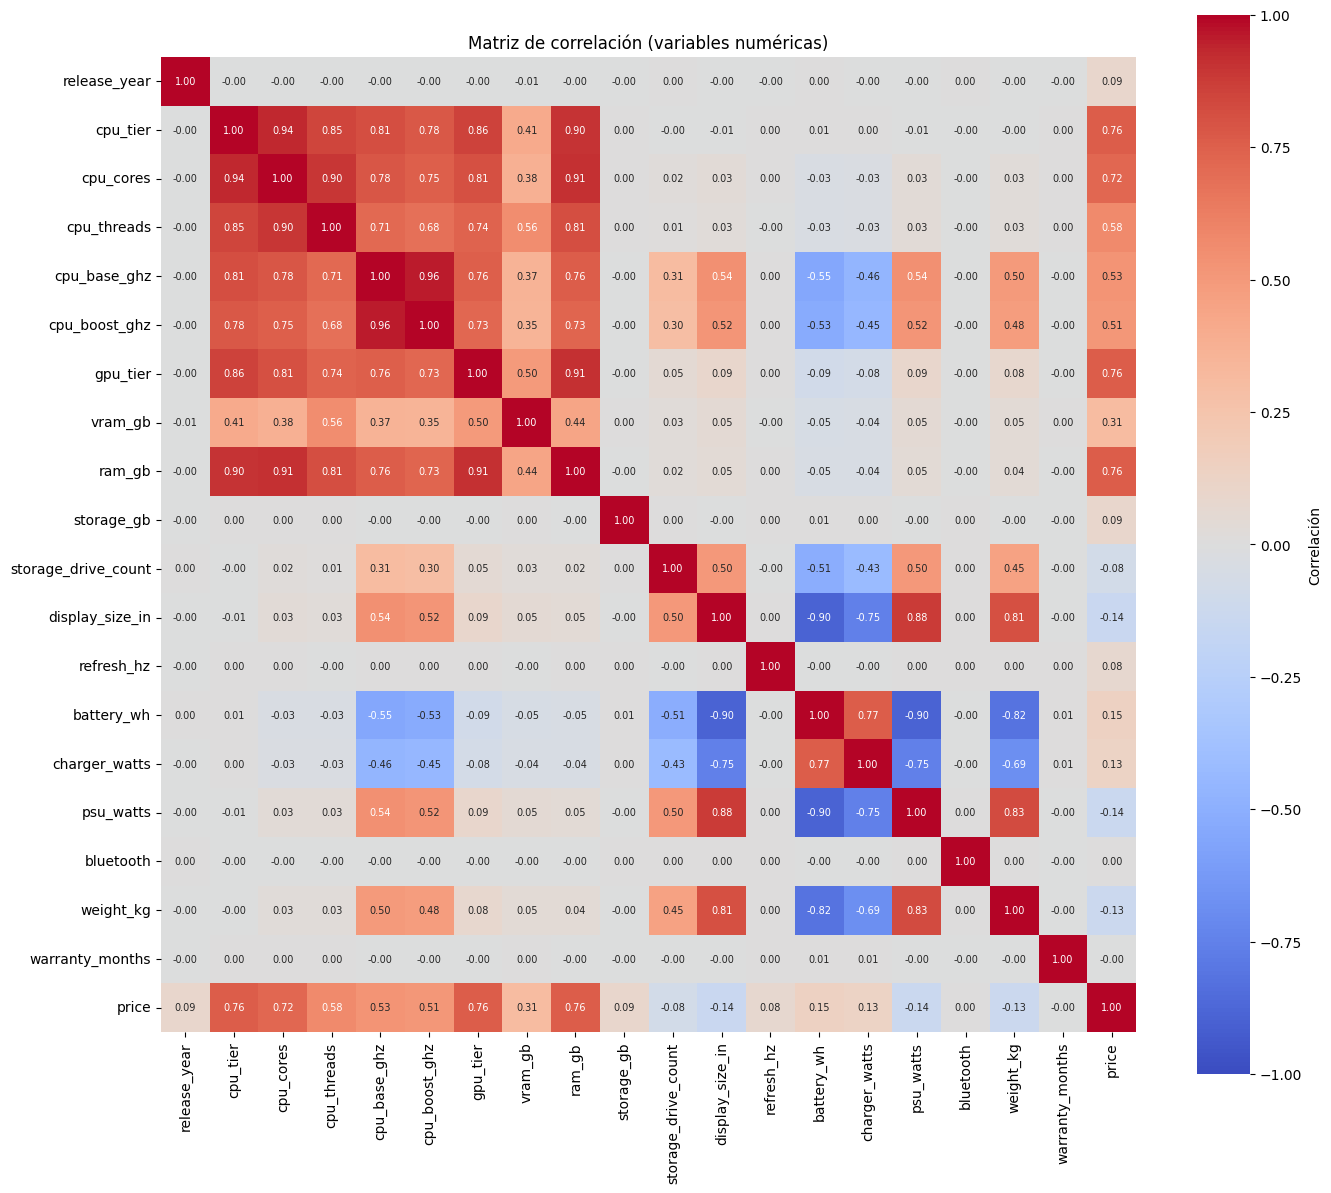

In [16]:
# Heatmap de correlación para variables numéricas
cols_num = compu_df.select_dtypes(include=[np.number]).columns.tolist()
base_num = compu_df[cols_num]
const_cols = base_num.columns[base_num.nunique(dropna=True) <= 1].tolist()
corr = base_num.corr(method="pearson")

n = corr.shape[0]
lado = max(6, min(0.6 * n + 2, 20))

fig, ax = plt.subplots(figsize=(lado, lado))
sns.heatmap(
    corr,
    ax=ax,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    annot=True, fmt='.2f',
    annot_kws={'fontsize': 7},
    cbar_kws={'shrink': 0.8, 'label': f'Correlación'}
)

ax.set_title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.show()

paso 4 feature selection, paso 5 feature transformation y paso 6 feature engineering

In [17]:
# eliminar model y cpu_model

# bluetooth, cpu_cores, warranty months

# compu_df.drop(columns=["model", "cpu_model", "cpu_cores", "ram_gb", "release_year"], inplace=True)

compu_df.drop(columns=["model", "cpu_model", "cpu_cores", "ram_gb"], inplace=True)

# Debemos proteger:

# 1. Exactitud
# 2. Estabilidad
# 3. Complegidad (Interpretabilidad)

compu_trans = compu_df.copy()

In [18]:
# años transcurridos desde el lanzamiento de cada computadora

s = compu_trans['release_year']

years = pd.Timestamp.now().year - pd.to_numeric(s, errors='coerce')
years = years.astype('Int64')
years = years.where(years >= 0)
compu_trans['years_since_release'] = years

compu_trans = compu_trans.drop(columns=['release_year'])

display(compu_trans.head())

,device_type,brand,os,form_factor,cpu_brand,cpu_tier,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,...,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price,years_since_release
0,Desktop,Samsung,Windows,ATX,Intel,3,24,2.8,3.8,NVIDIA,...,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99,4
1,Laptop,Samsung,Windows,Mainstream,Intel,4,24,2.6,3.6,NVIDIA,...,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99,4
2,Desktop,Lenovo,macOS,SFF,AMD,2,16,2.6,3.6,NVIDIA,...,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99,2
3,Desktop,Dell,Windows,ATX,AMD,2,12,2.6,3.6,AMD,...,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99,2
4,Laptop,Gigabyte,Linux,Gaming,AMD,5,32,2.8,3.9,NVIDIA,...,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99,2


In [45]:
# discretización de vram_gb
display(compu_trans["vram_gb"].drop_duplicates().sort_values())

s = compu_trans["vram_gb"]
s_nna = s.notna()
n_unique = s[s_nna].nunique()

n_bins_eff = 4
kb = KBinsDiscretizer(n_bins=n_bins_eff,encode='ordinal', strategy='quantile')
binned = np.full(shape=(len(compu_trans),), fill_value=np.nan, dtype=float)
binned[s_nna.values] = kb.fit_transform(s[s_nna].to_numpy().reshape(-1, 1)).ravel()
compu_trans["vram_gb_binned"] = pd.Series(binned, index=compu_trans.index).astype('Int64')

display(compu_trans["vram_gb_binned"].drop_duplicates().sort_values())

6      0
34     2
2      4
0      6
14     8
1     10
4     12
5     16
Name: vram_gb, dtype: int64

6    0
2    1
0    2
1    3
Name: vram_gb_binned, dtype: Int64

Limites Bin: [ 0.  4.  6.  8. 16.]
Bin 0: [0, 4): 20757 Registros
Bin 1: [4, 6): 20517 Registros
Bin 2: [6, 8): 17930 Registros
Bin 3: [8, 16]: 40796 Registros


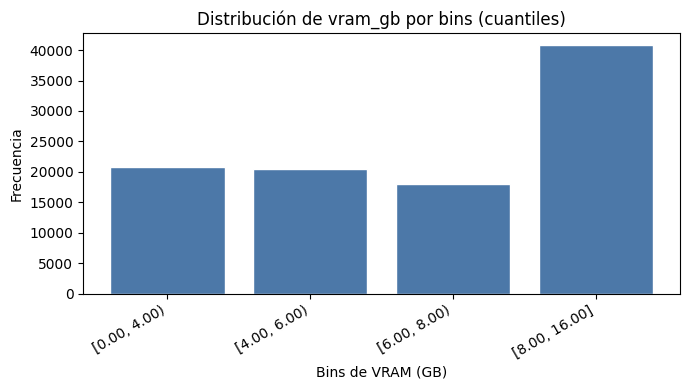

In [20]:
# histograma después de la transformación y limites de bins 

# bordes de los bins
edges = compu_trans['vram_gb'].quantile([0.0, 0.25, 0.50, 0.75, 1.0]).to_numpy()
b = compu_trans['vram_gb_binned'].to_numpy().astype(int)
counts = np.bincount(b, minlength=4)
print("Limites Bin:", edges)
for i in range(4):
    cierre = ')' if i < 3 else ']'
    print(f"Bin {i}: [{edges[i]:.4g}, {edges[i+1]:.4g}{cierre}: {counts[i]} Registros")

# histograma
b = compu_trans['vram_gb_binned'].to_numpy().astype(int)
counts = np.bincount(b, minlength=4)
labels = [f"[{edges[i]:.2f}, {edges[i+1]:.2f}{')' if i < 3 else ']'}" for i in range(4)]

plt.figure(figsize=(7, 4))
plt.bar(range(4), counts, color="#4C78A8", edgecolor="white")
plt.xticks(range(4), labels, rotation=30, ha='right')
plt.ylabel("Frecuencia")
plt.xlabel("Bins de VRAM (GB)")
plt.title("Distribución de vram_gb por bins (cuantiles)")
plt.tight_layout()
plt.show()

In [21]:
# valores unicos de charger watss
display(compu_trans["charger_watts"].drop_duplicates().sort_values())

# valores unicos de psu watss
display(compu_trans["psu_watts"].drop_duplicates().sort_values())

# valores unicos combinados de charger watss y psu watts
display(compu_trans[["psu_watts","charger_watts"]].drop_duplicates().sort_values( by = ["psu_watts","charger_watts"]))

0       0
9      45
14     65
4      90
1     120
15    180
8     240
Name: charger_watts, dtype: int64

1        0
24     300
22     450
13     550
3      650
0      750
2      850
5     1000
12    1200
Name: psu_watts, dtype: int64

,psu_watts,charger_watts
9,0,45
14,0,65
4,0,90
1,0,120
15,0,180
8,0,240
24,300,0
22,450,0
13,550,0
3,650,0


In [22]:
# creacion de power_watts para homologar psu_watts y charger_watts
compu_trans['power_watts'] = compu_trans.apply(lambda row: row['psu_watts'] if not row['psu_watts'] == 0 else row['charger_watts'], axis=1)

display(compu_trans[['psu_watts','charger_watts','power_watts']].drop_duplicates().sort_values(by=['power_watts','psu_watts','charger_watts']))

,psu_watts,charger_watts,power_watts
9,0,45,45
14,0,65,65
4,0,90,90
1,0,120,120
15,0,180,180
8,0,240,240
24,300,0,300
22,450,0,450
13,550,0,550
3,650,0,650


Text(0, 0.5, 'Frecuencia')

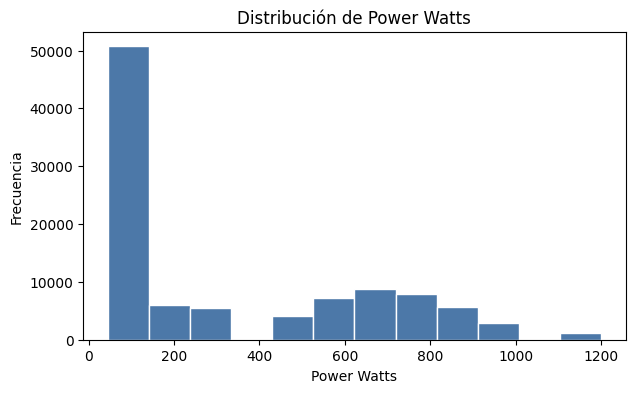

In [23]:
# histograma para verificación bimodal
plt.figure(figsize=(7, 4))
plt.hist(compu_trans['power_watts'].dropna(), bins=12, color="#4C78A8", edgecolor="white")
plt.title("Distribución de Power Watts")
plt.xlabel("Power Watts")
plt.ylabel("Frecuencia")

Text(715.0, 48180.2, 'mediana desktop 650W')

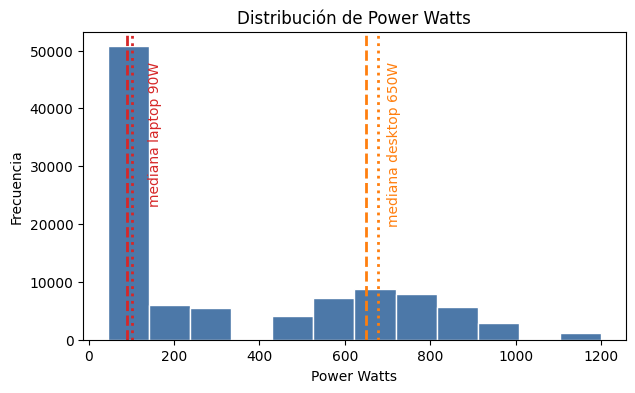

In [24]:
# histograma para validar bimodalidad (con valores de referencia)
ch = compu_trans['charger_watts'].replace(0, np.nan).dropna().astype(float)
ps = compu_trans['psu_watts'].replace(0, np.nan).dropna().astype(float)

med_ch = ch.median()
med_ps = ps.median()

avg_ch = ch.mean()
avg_ps = ps.mean()

plt.figure(figsize=(7, 4))
counts, bins, _ = plt.hist(compu_trans['power_watts'].dropna(), bins=12, color="#4C78A8", edgecolor="white")
plt.title("Distribución de Power Watts")
plt.xlabel("Power Watts")
plt.ylabel("Frecuencia")

y_top = counts.max()
x_top_1 = max(med_ch,avg_ch)
x_top_2 = max(med_ps,avg_ps)

plt.axvline(med_ch, color='tab:red', linestyle='--', linewidth=2, label=f"Mediana charger = {med_ch:.0f} W")
plt.axvline(avg_ch, color='tab:red', linestyle=':',  linewidth=2, label=f"Promedio charger = {avg_ch:.0f} W")

plt.axvline(med_ps, color='tab:orange', linestyle='--', linewidth=2, label=f"Mediana psu = {med_ps:.0f} W")
plt.axvline(avg_ps, color='tab:orange', linestyle=':',  linewidth=2, label=f"Promedio psu = {avg_ps:.0f} W")

plt.text(med_ch + 65, y_top*0.95, f"mediana laptop {med_ch:.0f}W", rotation=90, va='top', ha='center', color='tab:red')
plt.text(med_ps + 65, y_top*0.95, f"mediana desktop {med_ps:.0f}W", rotation=90, va='top', ha='center', color='tab:orange')

In [ ]:
# prueba estadistica de bimodalidad
x = compu_trans["power_watts"].dropna().to_numpy().reshape(-1, 1)
g1 = GaussianMixture(n_components=1, random_state=0).fit(x)    # Prueba de bimodalidad: indicamos la cantidad de componentes y comparamos: Genera los parametros de estos datos basados en una distribucion de una sola moda
g2 = GaussianMixture(n_components=2, random_state=0).fit(x)
print("BIC(1):", g1.bic(x))    # BIC: Bayesian Information Criterion, es una medida de la calidad de un modelo estadístico para un conjunto de datos dado. Penaliza la complejidad del modelo (número de parámetros) y recompensa el ajuste a los datos. Un BIC más bajo indica un mejor equilibrio entre ajuste y simplicidad.
print("BIC(2):", g2.bic(x))    # Se usa para checar si la distribución es bimodal o no, si el BIC de 2 componentes es significativamente menor que el de 1 componente, esto sugiere que una distribución bimodal se ajusta mejor a los datos que una unimodal. En este caso, si BIC(2) < BIC(1), podríamos concluir que la distribución de power_watts es bimodal.

BIC(1): 1431320.4558796023
BIC(2): 1294528.4780033475


In [26]:
# eliminar las variables originales de charger_watts y psu_watts
compu_trans = compu_trans.drop(columns=['charger_watts', 'psu_watts'])
display(compu_trans.head())

,device_type,brand,os,form_factor,cpu_brand,cpu_tier,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,...,refresh_hz,battery_wh,wifi,bluetooth,weight_kg,warranty_months,price,years_since_release,vram_gb_binned,power_watts
0,Desktop,Samsung,Windows,ATX,Intel,3,24,2.8,3.8,NVIDIA,...,90,0,Wi-Fi 6,5.1,11.00,36,1383.99,4,2,750
1,Laptop,Samsung,Windows,Mainstream,Intel,4,24,2.6,3.6,NVIDIA,...,90,56,Wi-Fi 6,5.3,2.03,12,2274.99,4,3,120
2,Desktop,Lenovo,macOS,SFF,AMD,2,16,2.6,3.6,NVIDIA,...,120,0,Wi-Fi 6,5.0,7.00,24,1879.99,2,1,850
3,Desktop,Dell,Windows,ATX,AMD,2,12,2.6,3.6,AMD,...,120,0,Wi-Fi 6,5.2,6.00,36,1331.99,2,2,650
4,Laptop,Gigabyte,Linux,Gaming,AMD,5,32,2.8,3.9,NVIDIA,...,90,80,Wi-Fi 6,5.2,1.50,12,2681.99,2,3,90


7 separacion train y test

Sobre `train` vamos a obtener un accuaracy preeliminar. Puede ocurrir algo que se llama *overfitting* (sobreajuste). Puede suceder si tiene informacion con colinealidad o informacion muy relacionado con la variable objetivo. En vez de que el modelo aprendiera, este memorizo.

Ej. le diste 100 valores, predijo 99. Ahora se aplica sobre informacion que no conoce (pues es la unica manera de saber su efectividad real, sobre informacion bajo la que no esta entrenada). Supongamos que con *test* su accuaracy es de *25*. En este caso esta haciendo overfitting, esta memorizando, no aprendiendo.

Hay tecnicas para reducir el overfitting.

Cuando hay muy poca muestra, se aplica crossvalidation. Se aplican submuestras de test (de la informacion de test le escondemos un cachito, e.g. lo partimos en 5 partes, a cada cachito le aplica una metrica, y al final se saca el promedio).

El train y el test tienen que ser aleatorios. Hay modelos que tienen orden temporal (por ejemplo en modelos bursatiles, pues estan acomodados en forma temporal)

**Tiene que ir desde el inicio para evitar la fuga de informacion** (justo despues de la lectura de datos).

Tipos de fuga de datos:

1. Interpretacion: Supongamos que en el EDA haya salido una variable que intuimos describe la distribucion de la variable objetivo. Desde esta interpretacion ya no debes de tener
2. Constuccion: Cuando hacemos transformaciones (como la formalizacion), podria sesgar la informacion. Tambien la imputacion podria sesgar la informacion. Si se hace esto con informacion de test, lo estamos haciendo con informacion adelantada.
3. Entrenamiento:

Mientras mas normalizada este la distribucion de la variable objetivo, mas facil va ser de modelar.

(en un contexto real y no académico, la separación de train y test debe realizarse inmediatamente después a la lectura de variables para evitar data leakage)

In [ ]:
# train:  70%, 80%, 85%, 90%
# test:  30%, 20%, 15%, 10%

random_state = 42

train_size = 0.85
test_size = 1 - train_size

rand_numbers_list = np.random.RandomState(seed=random_state).permutation(len(compu_trans))
rand_numbers_list_train = rand_numbers_list[:int(len(compu_trans) * train_size)]
rand_numbers_list_test = rand_numbers_list[int(len(compu_trans) * train_size):]

y_train = compu_trans["price"][rand_numbers_list_train]
y_test = compu_trans["price"][rand_numbers_list_test]

x_train = compu_trans.drop(columns=["price"]).iloc[rand_numbers_list_train]
x_test = compu_trans.drop(columns=["price"]).iloc[rand_numbers_list_test]

8 separación "X" y "Y" (análisis de variable objetivo)

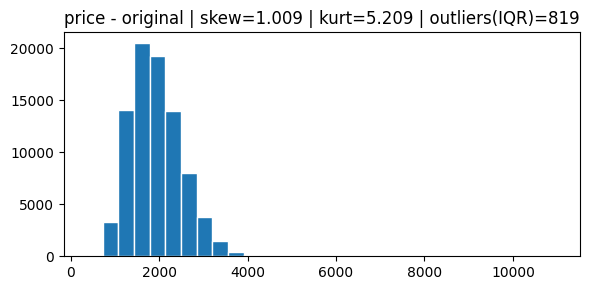

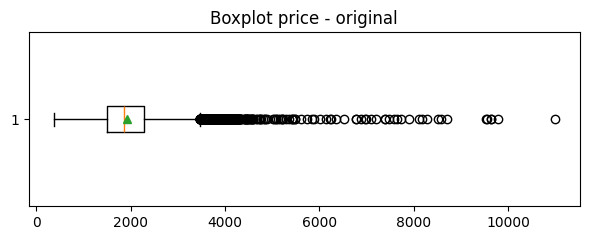

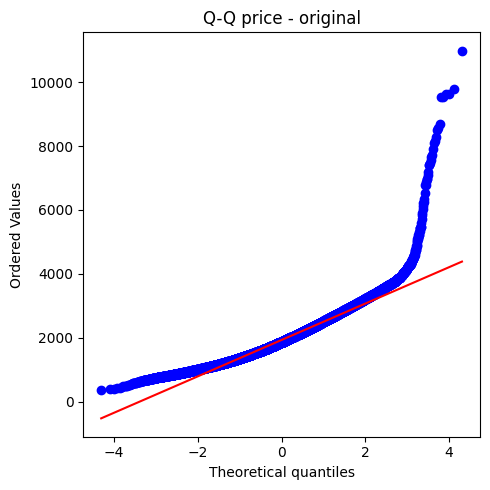

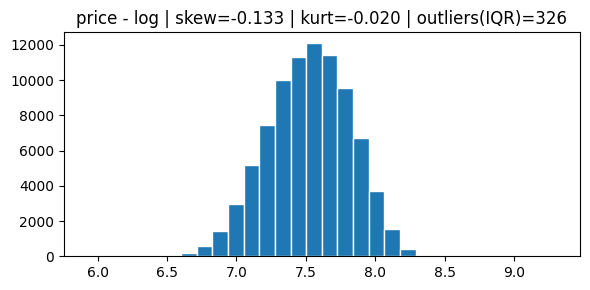

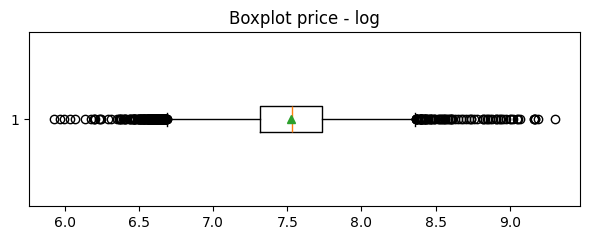

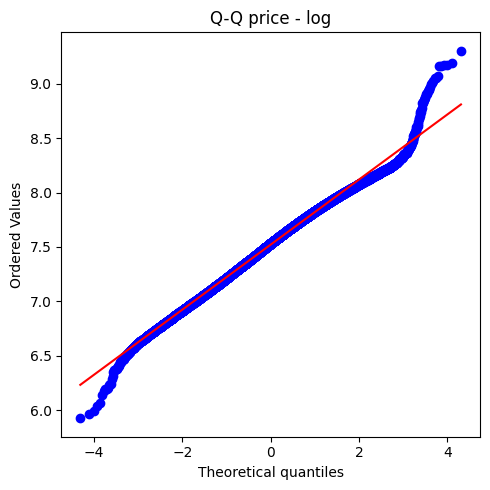

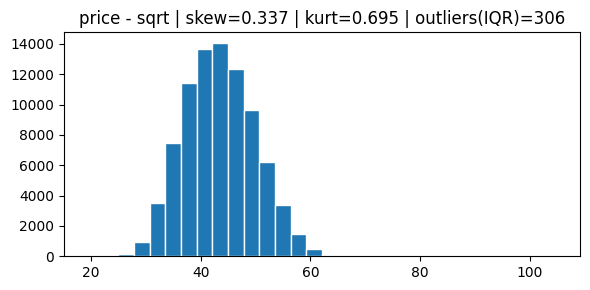

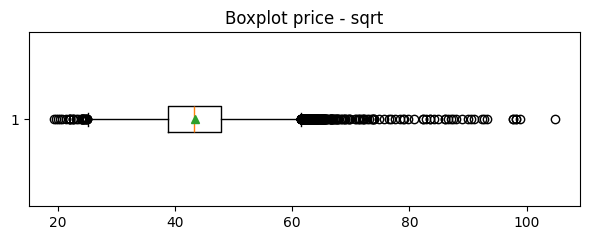

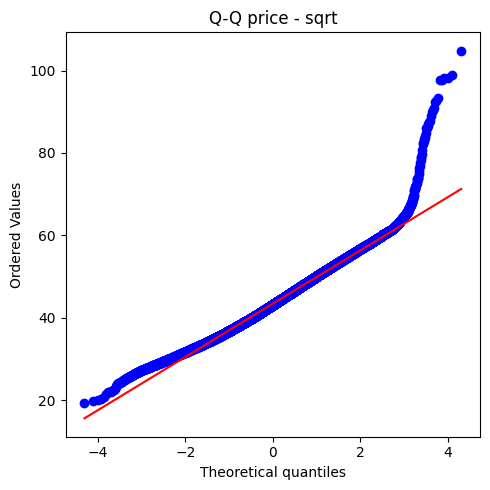

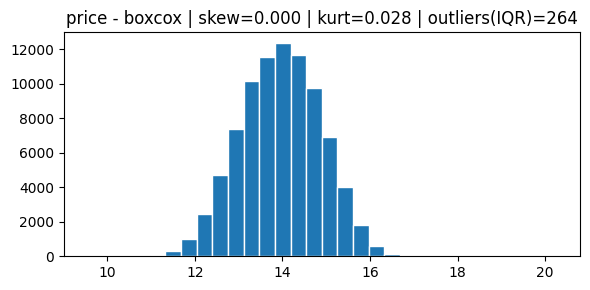

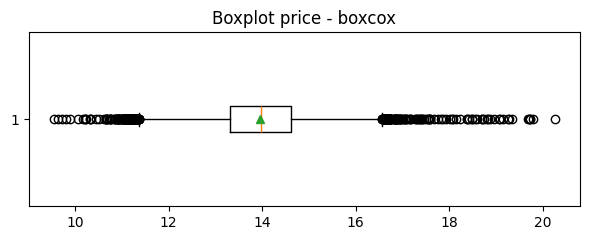

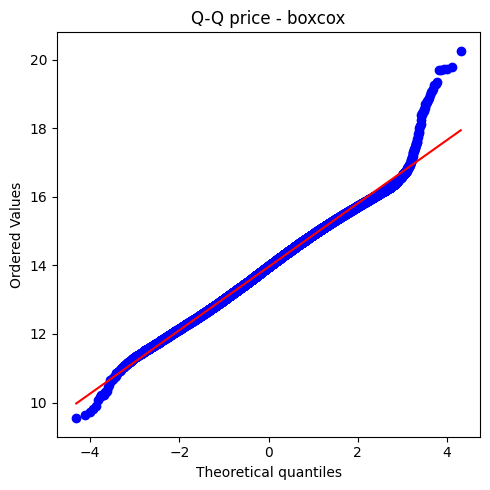

In [28]:
y_train = pd.Series(y_train).dropna().astype(float)

y_original = y_train.copy()
y_log = np.log1p(y_original)
y_sqrt = np.sqrt(y_original)

y_pos = y_train.copy()
if y_pos.min() <= 0:
    y_pos = y_pos + (abs(y_pos.min()) + 1e-6)

pt_single = PowerTransformer(method="box-cox", standardize=False)
y_boxcox = pt_single.fit_transform(y_pos.to_numpy().reshape(-1, 1)).ravel()
y_boxcox = pd.Series(y_boxcox, index=y_pos.index)

q1 = y_original.quantile(0.25); q3 = y_original.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr; hi = q3 + 1.5 * iqr
out_original = int(((y_original < lo) | (y_original > hi)).sum())
sk_original = float(y_original.skew())
ku_original = float(y_original.kurt())

q1 = y_log.quantile(0.25); q3 = y_log.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr; hi = q3 + 1.5 * iqr
out_log = int(((y_log < lo) | (y_log > hi)).sum())
sk_log = float(y_log.skew())
ku_log = float(y_log.kurt())

q1 = y_sqrt.quantile(0.25); q3 = y_sqrt.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr; hi = q3 + 1.5 * iqr
out_sqrt = int(((y_sqrt < lo) | (y_sqrt > hi)).sum())
sk_sqrt = float(y_sqrt.skew())
ku_sqrt = float(y_sqrt.kurt())

q1 = y_boxcox.quantile(0.25); q3 = y_boxcox.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr; hi = q3 + 1.5 * iqr
out_boxcox = int(((y_boxcox < lo) | (y_boxcox > hi)).sum())
sk_boxcox = float(y_boxcox.skew())
ku_boxcox = float(y_boxcox.kurt())

plt.figure(figsize=(6,3))
plt.hist(y_original, bins=30, edgecolor="white")
plt.title(f"price - original | skew={sk_original:.3f} | kurt={ku_original:.3f} | outliers(IQR)={out_original}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,2.5))
plt.boxplot(y_original, vert=False, showmeans=True)
plt.title("Boxplot price - original")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,5))
probplot(y_original, dist="norm", plot=plt)
plt.title("Q-Q price - original")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
plt.hist(y_log, bins=30, edgecolor="white")
plt.title(f"price - log | skew={sk_log:.3f} | kurt={ku_log:.3f} | outliers(IQR)={out_log}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,2.5))
plt.boxplot(y_log, vert=False, showmeans=True)
plt.title("Boxplot price - log")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,5))
probplot(y_log, dist="norm", plot=plt)
plt.title("Q-Q price - log")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
plt.hist(y_sqrt, bins=30, edgecolor="white")
plt.title(f"price - sqrt | skew={sk_sqrt:.3f} | kurt={ku_sqrt:.3f} | outliers(IQR)={out_sqrt}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,2.5))
plt.boxplot(y_sqrt, vert=False, showmeans=True)
plt.title("Boxplot price - sqrt")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,5))
probplot(y_sqrt, dist="norm", plot=plt)
plt.title("Q-Q price - sqrt")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
plt.hist(y_boxcox, bins=30, edgecolor="white")
plt.title(f"price - boxcox | skew={sk_boxcox:.3f} | kurt={ku_boxcox:.3f} | outliers(IQR)={out_boxcox}")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,2.5))
plt.boxplot(y_boxcox, vert=False, showmeans=True)
plt.title("Boxplot price - boxcox")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,5))
probplot(y_boxcox, dist="norm", plot=plt)
plt.title("Q-Q price - boxcox")
plt.tight_layout()
plt.show()

Paso 9 Codificación de categorías

Determinar que transformacion aplicar en tipos de datos categoricos: Que es mucho y que es poco? Depende de cuantos registros se tiene y que tanto valor tiene la informacion contenida en el. Corre el riesgo de agregar sobre-representacion. Equitativamente representativo respecto a la cantidad d ereesigstros y a la cantidad de variables seleccionadas.

Ya no podemos aplicar one hot encoding. Con el binary encoding - reduce la dimesion previniendo problemas de colinealidad.

In [29]:
# Binary Encoding para gpu_model

binary_cols = ["gpu_model"]
bin_encoder = BinaryEncoder(cols=binary_cols)
x_train_binary = bin_encoder.fit_transform(x_train[binary_cols])

display(x_train_binary.head())

,gpu_model_0,gpu_model_1,gpu_model_2,gpu_model_3,gpu_model_4,gpu_model_5
75721,0,0,0,0,0,1
80184,0,0,0,0,1,0
19864,0,0,0,0,1,1
76699,0,0,0,1,0,0
92991,0,0,0,0,1,1


In [30]:
cat_cols = x_train.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "gpu_model"]

ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
ohe_arr = ohe.fit_transform(x_train[cat_cols])
ohe_df = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out(cat_cols), index=x_train.index)


base_df = x_train.drop(columns=cat_cols + ["gpu_model"])
compu_trans_train = pd.concat([base_df, x_train_binary, ohe_df], axis=1)

display(compu_trans_train.describe())
display(compu_trans_train.describe().T[["min","max"]].head(25))
display(compu_trans_train.head())

,cpu_tier,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,storage_gb,storage_drive_count,display_size_in,refresh_hz,...,display_type_QLED,display_type_VA,resolution_2560x1440,resolution_2560x1600,resolution_2880x1800,resolution_3440x1440,resolution_3840x2160,wifi_Wi-Fi 6,wifi_Wi-Fi 6E,wifi_Wi-Fi 7
count,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,...,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000,85000.000000
mean,3.154235,19.371671,2.591544,3.531488,2.991624,6.140071,902.469271,1.526247,20.126927,98.493141,...,0.100176,0.060671,0.144906,0.149259,0.059753,0.057188,0.108847,0.461165,0.258906,0.080565
std,1.373531,9.730128,0.336718,0.350547,1.459630,3.969662,772.778274,0.799191,6.710266,43.318716,...,0.300237,0.238726,0.352008,0.356346,0.237030,0.232203,0.311449,0.498492,0.438036,0.272167
min,1.000000,4.000000,2.000000,2.800000,1.000000,0.000000,256.000000,1.000000,13.300000,60.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,12.000000,2.400000,3.300000,2.000000,4.000000,512.000000,1.000000,14.000000,60.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,16.000000,2.600000,3.500000,3.000000,6.000000,512.000000,1.000000,16.000000,90.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,24.000000,2.800000,3.800000,4.000000,8.000000,1024.000000,2.000000,27.000000,120.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,6.000000,56.000000,3.400000,4.500000,6.000000,16.000000,4096.000000,4.000000,34.000000,240.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


,min,max
cpu_tier,1.0,6.0
cpu_threads,4.0,56.0
cpu_base_ghz,2.0,3.4
cpu_boost_ghz,2.8,4.5
gpu_tier,1.0,6.0
vram_gb,0.0,16.0
storage_gb,256.0,4096.0
storage_drive_count,1.0,4.0
display_size_in,13.3,34.0
refresh_hz,60.0,240.0


,cpu_tier,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,storage_gb,storage_drive_count,display_size_in,refresh_hz,...,display_type_QLED,display_type_VA,resolution_2560x1440,resolution_2560x1600,resolution_2880x1800,resolution_3440x1440,resolution_3840x2160,wifi_Wi-Fi 6,wifi_Wi-Fi 6E,wifi_Wi-Fi 7
75721,3,16,2.4,3.5,2,6,256,1,15.6,120,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
80184,1,16,2.4,3.3,1,4,4096,1,27.0,144,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
19864,5,32,3.2,4.0,4,2,256,3,27.0,144,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
76699,4,24,2.6,3.7,4,10,1024,1,15.6,60,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
92991,3,18,2.8,3.8,3,0,512,1,27.0,120,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Paso 10 imputar faltantes (en este caso no hay faltantes) y tratamiento de outliers (estudiar: IQR y Winzorizacion)

In [31]:
# Imputaciones principales:
# --- Media
# --- Mediana
# --- Valor Constante (con criterio experto)
# ---- Eliminar
# ---- Imputación avanzada (modelos predictivos, KNN, etc)

Paso 11 escalar variables

In [32]:
scaler = MinMaxScaler()

x_train_scaled_arr = scaler.fit_transform(compu_trans_train)

x_train_scaled = pd.DataFrame(
    x_train_scaled_arr,
    columns=compu_trans_train.columns,
    index=compu_trans_train.index
)

# 6. Validación
display(x_train_scaled.head())
display(x_train_scaled.describe().T[["min", "max"]])

,cpu_tier,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,storage_gb,storage_drive_count,display_size_in,refresh_hz,...,display_type_QLED,display_type_VA,resolution_2560x1440,resolution_2560x1600,resolution_2880x1800,resolution_3440x1440,resolution_3840x2160,wifi_Wi-Fi 6,wifi_Wi-Fi 6E,wifi_Wi-Fi 7
75721,0.4,0.230769,0.285714,0.411765,0.2,0.375,0.000000,0.000000,0.111111,0.333333,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
80184,0.0,0.230769,0.285714,0.294118,0.0,0.250,1.000000,0.000000,0.661836,0.466667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
19864,0.8,0.538462,0.857143,0.705882,0.6,0.125,0.000000,0.666667,0.661836,0.466667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
76699,0.6,0.384615,0.428571,0.529412,0.6,0.625,0.200000,0.000000,0.111111,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
92991,0.4,0.269231,0.571429,0.588235,0.4,0.000,0.066667,0.000000,0.661836,0.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,min,max
cpu_tier,0.0,1.0
cpu_threads,0.0,1.0
cpu_base_ghz,0.0,1.0
cpu_boost_ghz,0.0,1.0
gpu_tier,0.0,1.0
...,...,...
resolution_3440x1440,0.0,1.0
resolution_3840x2160,0.0,1.0
wifi_Wi-Fi 6,0.0,1.0
wifi_Wi-Fi 6E,0.0,1.0


Paso 12 pipeline

El pipeline es como una secuencia de pasos predefinido que te va resolviendo el problema. 

Ej. de pipeline en data engineering: Llega la capa *raw* y se hace la 1ra transformacion que es el ordenamiento de datos. El 2da paso es la depuracion.

En ciencia de datos hay pipelines. Como se hicieron ciertas trasnformaciones y cierta imputaciones de nulos. Tengo que asegurarme de que cada nuevo dataset siga el **pipeline** definido.

Variables a tomar en cuenta a la hora de decidir la estrategia de imputacion de datos para variables categoricas?

1. Que tan significativo es para la predictivilidad
    - Es importante pero si me interesa que conserve la relacion uso KNN o dejo un np.nan o algo similar
2. Que tan importante es el criterio de experto
3. Que tantos valores faltan

In [33]:
X_train_model = x_train.copy()
y_train_model = y_train.copy()

# 2. Definir columnas por tipo
binary_cols = ["gpu_model"]

cat_cols_pipe = X_train_model.select_dtypes(
    include=["object", "string", "category", "bool"]
).columns.tolist()

ohe_cols_pipe = [c for c in cat_cols_pipe if c not in binary_cols]

num_cols_pipe = X_train_model.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Columnas numéricas:", len(num_cols_pipe))
print("Columnas One Hot:", len(ohe_cols_pipe))
print("Columnas Binary:", binary_cols)

Columnas numéricas: 17
Columnas One Hot: 10
Columnas Binary: ['gpu_model']


In [34]:
# pipeline numerico
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

In [35]:
# pipeline categoricas ohe
ohe_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [ ]:
# pipeline Binary
binary_pipeline = Pipeline(steps=[
    ("binary", BinaryEncoder(
        cols=binary_cols,
        handle_unknown="value",
        handle_missing="value"
    ))
])

In [ ]:
# preprocessior - Pipeline de pre-processamiento.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols_pipe),
        ("gpu_binary", binary_pipeline, binary_cols),
        ("cat_ohe", ohe_pipeline, ohe_cols_pipe)
    ],
    remainder="drop"
)

In [ ]:
# pipeline integrado - Pipeline global

modelo_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

Paso 13 entrenamiento

In [39]:
modelo_pipeline.fit(X_train_model, y_train_model)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['cpu_tier', 'cpu_threads',
                                                   'cpu_base_ghz',
                                                   'cpu_boost_ghz', 'gpu_tier',
                                                   'vram_gb', 'storage_gb',
                                                   'storage_drive_count',
                                                   'display_size_in',
                                                   'refresh_hz', 'battery_wh',
                                                   'bluetooth', 'weight_kg',
                                                   'warrant...
                                                                   BinaryEncoder(cols=['gpu_model']))]),
                                                  ['gpu_model']),
                                                 ('cat_ohe',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['device_type', 'brand', 'os',
                                                   'form_factor', 'cpu_brand',
                                                   'gpu_brand', 'storage_type',
                                                   'display_type', 'resolution',
                                                   'wifi'])])),
                ('model', LinearRegression())])

In [46]:
# metricas de train
y_train_pred = modelo_pipeline.predict(X_train_model)
mae_train = mean_absolute_error(y_train_model, y_train_pred)
mape_train = np.mean(np.abs((y_train_model - y_train_pred) / y_train_model)) * 100
mse_train = mean_squared_error(y_train_model, y_train_pred)
rmse_train = mean_squared_error(y_train_model, y_train_pred)**(1/2)
r2_train = r2_score(y_train_model, y_train_pred)

print(f"MAE Train: {mae_train:.2f}")
print(f"MAPE Train: {mape_train:.2f}%")
print(f"MSE Train: {mse_train:.2f}")
print(f"RMSE Train: {rmse_train:.2f}")
print(f"R2 Train: {r2_train:.4f}")

MAE Train: 146.60
MAPE Train: 7.81%
MSE Train: 50650.89
RMSE Train: 225.06
R2 Train: 0.8501


- MAE: Minimum absolute error
- MAPE: Minimum absolute percentage error
- MSE: Minimum squared error
- R2: R-squared


Paso 14 evaluación

In [41]:
# Predicción sobre test crudo
y_test_pred = modelo_pipeline.predict(x_test)

# Métricas principales
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = mse_test ** 0.5
r2_test = r2_score(y_test, y_test_pred)

# MAPE, evitando división entre cero
mask_mape = y_test != 0

if mask_mape.sum() > 0:
    mape_test = np.mean(
        np.abs((y_test[mask_mape] - y_test_pred[mask_mape]) / y_test[mask_mape])
    ) * 100
else:
    mape_test = np.nan

# Tabla resumen de métricas
metricas_test = pd.DataFrame({
    "Metrica": ["MAE", "MSE", "RMSE", "R2", "MAPE"],
    "Valor": [mae_test, mse_test, rmse_test, r2_test, mape_test]
})

display(metricas_test)

# Tabla de resultados reales vs predichos
resultados_test = pd.DataFrame({
    "y_real": y_test,
    "y_pred": y_test_pred
})

resultados_test["residual"] = resultados_test["y_real"] - resultados_test["y_pred"]
resultados_test["error_absoluto"] = np.abs(resultados_test["residual"])

resultados_test["error_porcentual"] = np.where(
    resultados_test["y_real"] != 0,
    resultados_test["error_absoluto"] / resultados_test["y_real"] * 100,
    np.nan
)

display(resultados_test.head(20))

,Metrica,Valor
0,MAE,143.795831
1,MSE,45905.339751
2,RMSE,214.255314
3,R2,0.861390
4,MAPE,7.683685


,y_real,y_pred,residual,error_absoluto,error_porcentual
59967,1554.99,1670.630117,-115.640117,115.640117,7.436711
26485,2873.99,2805.603769,68.386231,68.386231,2.379487
34297,1796.99,1886.511062,-89.521062,89.521062,4.981723
1286,1536.99,1577.103957,-40.113957,40.113957,2.609904
48398,2203.99,2186.774507,17.215493,17.215493,0.781106
15059,3181.99,3013.581706,168.408294,168.408294,5.292546
88339,1242.99,1167.941664,75.048336,75.048336,6.037726
87571,2572.99,2582.406009,-9.416009,9.416009,0.365956
12454,1916.99,2038.578023,-121.588023,121.588023,6.342653
21699,1432.99,1643.929728,-210.939728,210.939728,14.720251


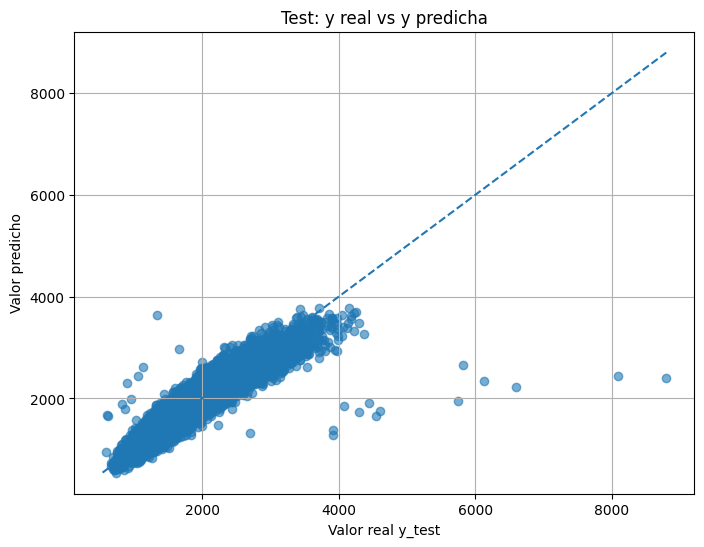

In [42]:
# Gráfico y_test vs y_predicha en test

# Predicción sobre test crudo usando el pipeline
y_test_pred = modelo_pipeline.predict(x_test)

# Crear dataframe comparativo
df_pred_test = pd.DataFrame({
    "y_test": y_test,
    "y_predicha": y_test_pred
})

# Gráfico
plt.figure(figsize=(8, 6))

plt.scatter(
    df_pred_test["y_test"],
    df_pred_test["y_predicha"],
    alpha=0.6
)

# Línea ideal: predicción perfecta
min_val = min(df_pred_test["y_test"].min(), df_pred_test["y_predicha"].min())
max_val = max(df_pred_test["y_test"].max(), df_pred_test["y_predicha"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Valor real y_test")
plt.ylabel("Valor predicho")
plt.title("Test: y real vs y predicha")
plt.grid(True)
plt.show()

Paso 15 despliegue y documentación

In [43]:
# Crear carpeta de salida
output_dir = Path("modelo_despliegue")
output_dir.mkdir(exist_ok=True)

# Definir timestamp para versionar archivos
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Guardar pipeline completo
model_path = output_dir / f"modelo_pipeline_{timestamp}.pkl"

joblib.dump(modelo_pipeline, model_path)

print("Modelo guardado en:")
print(model_path)

Modelo guardado en:
modelo_despliegue\modelo_pipeline_20260516_090232.pkl


Parte de la pos-produccion, habria que checar el `PCI`. - PENDIENTE CHECAR

Una opcion es una prueba de KS